       OutdoorTemperature  IndoorTemperature  AC_Setpoint  DesiredTemperature  \
count         2800.000000        2800.000000  2800.000000        2.800000e+03   
mean            25.034425          23.047950    23.115293        2.333000e+01   
std              7.118706           7.143958     1.018338        3.553348e-15   
min             12.130000           9.960000    22.000000        2.333000e+01   
25%             18.137500          16.147500    22.130000        2.333000e+01   
50%             25.020000          23.010000    22.960000        2.333000e+01   
75%             32.080000          30.122500    23.820000        2.333000e+01   
max             37.150000          35.790000    27.230000        2.333000e+01   

         Occupancy  ElectricityPrice  ShiftableLoad  NonShiftableLoad  \
count  2800.000000       2800.000000    2800.000000       2800.000000   
mean      1.330357          0.123856       1.283877          1.741939   
std       1.076797          0.035845       0.725037

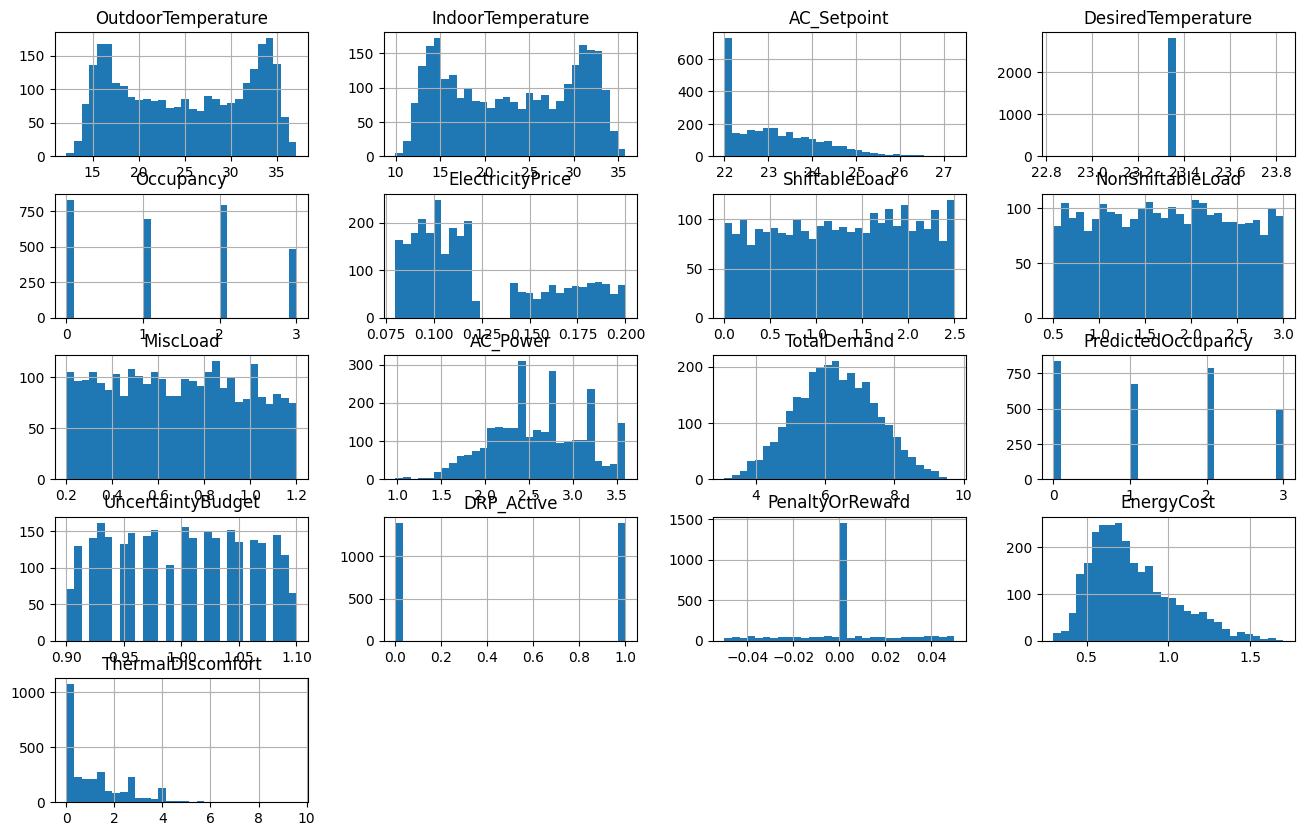

ValueError: could not convert string to float: '2022-06-01 00:00:00'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 1. Load Data
df = pd.read_csv("residential_demand_response_dataset.csv")

# 2. Data Preprocessing
df = df.dropna()        # Remove missing values
df = df.drop_duplicates() # Remove duplicates

# 3. EDA (Exploratory Data Analysis)
print(df.describe())
df.hist(bins=30, figsize=(16, 10))
plt.show()
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.show()

# 4. Define Input Features and Target
input_features = [
    "OutdoorTemperature", "IndoorTemperature", "ACSetpoint", "DesiredTemperature",
    "ElectricityPrice", "ShiftableLoad", "NonShiftableLoad", "MiscLoad", "ACPower", "TotalDemand"
]
target_col = "Occupancy"

X = df[input_features]
y = df[target_col]

# 5. Feature Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 6. Optional: Feature Importance
rf_temp = RandomForestRegressor(n_estimators=50, random_state=1)
rf_temp.fit(X_scaled, y)
importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(len(input_features)):
    print(f"{f+1}. {input_features[indices[f]]} ({importances[indices[f]]:.3f})")

# 7. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8. Model Training

# a) Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
joblib.dump(rf, "model_random_forest.pkl")

# b) LightGBM
lgbm = LGBMRegressor(n_estimators=100, random_state=0)
lgbm.fit(X_train, y_train)
joblib.dump(lgbm, "model_lightgbm.pkl")

# c) MLP-ANN
mlp = MLPRegressor(hidden_layer_sizes=(32, 32), activation='relu', max_iter=300, random_state=0)
mlp.fit(X_train, y_train)
joblib.dump(mlp, "model_mlp_ann.pkl")

# 9. Model Evaluation
def evaluate(model, X, y):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    print(f"MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")
    return mse, rmse, mae, r2

print("Random Forest Performance:")
evaluate(rf, X_test, y_test)

print("LightGBM Performance:")
evaluate(lgbm, X_test, y_test)

print("MLP-ANN Performance:")
evaluate(mlp, X_test, y_test)


                 Timestamp  OutdoorTemperature  IndoorTemperature  \
count                 2800         2800.000000        2800.000000   
mean   2022-07-29 07:30:00           25.034425          23.047950   
min    2022-06-01 00:00:00           12.130000           9.960000   
25%    2022-06-30 03:45:00           18.137500          16.147500   
50%    2022-07-29 07:30:00           25.020000          23.010000   
75%    2022-08-27 11:15:00           32.080000          30.122500   
max    2022-09-25 15:00:00           37.150000          35.790000   
std                    NaN            7.118706           7.143958   

       AC_Setpoint  DesiredTemperature    Occupancy  ElectricityPrice  \
count  2800.000000        2.800000e+03  2800.000000       2800.000000   
mean     23.115293        2.333000e+01     1.330357          0.123856   
min      22.000000        2.333000e+01     0.000000          0.080000   
25%      22.130000        2.333000e+01     0.000000          0.095000   
50%      22.9

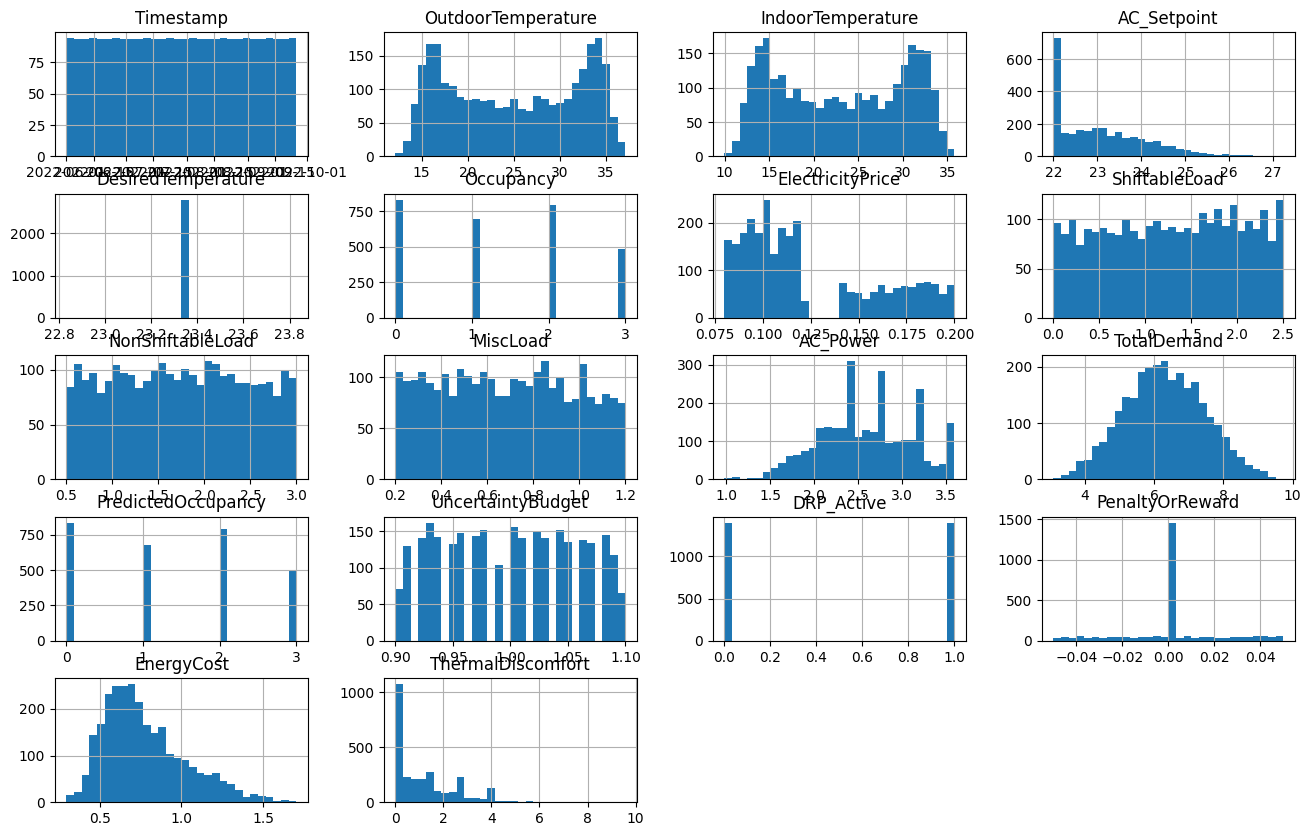

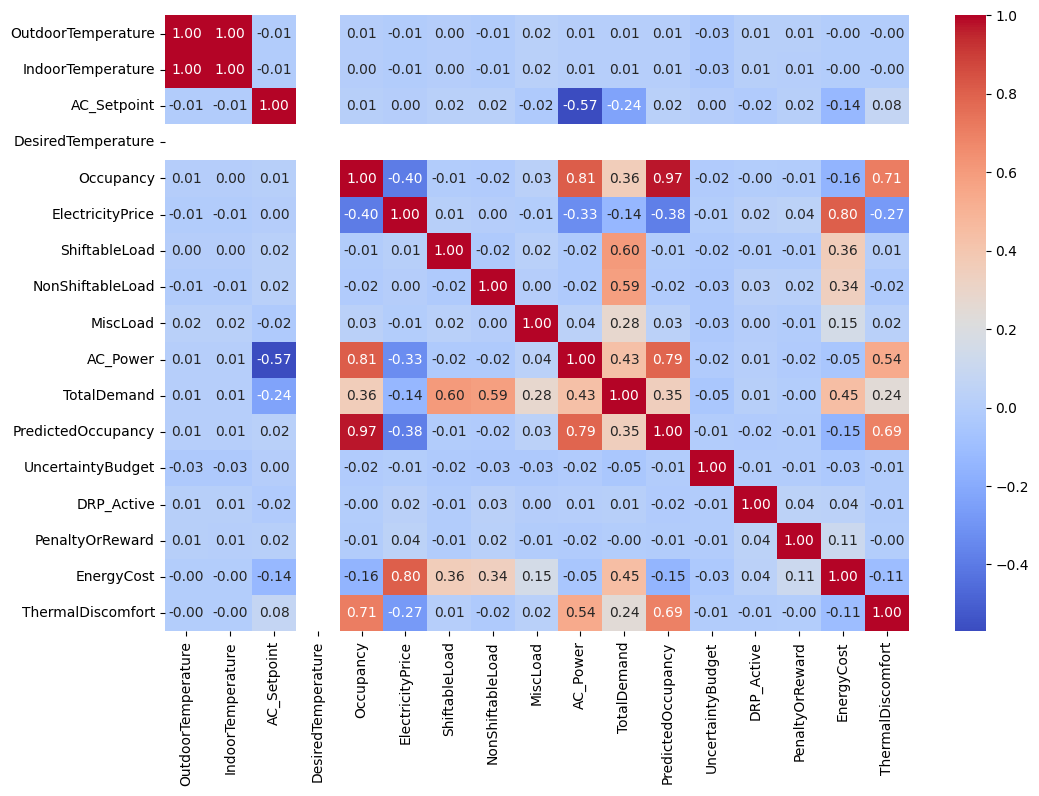

KeyError: "['ACSetpoint', 'ACPower'] not in index"

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 1. Load Data
df = pd.read_csv("residential_demand_response_dataset.csv")

# 2. Data Preprocessing
df = df.dropna()          # Remove missing values
df = df.drop_duplicates() # Remove duplicates

# Convert Timestamp to datetime if exists
if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# 3. EDA (Exploratory Data Analysis)
print(df.describe())

# Histograms
df.hist(bins=30, figsize=(16, 10))
plt.show()

# Correlation Heatmap (numeric columns only)
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

# 4. Define Input Features and Target
input_features = [
    "OutdoorTemperature", "IndoorTemperature", "ACSetpoint", "DesiredTemperature",
    "ElectricityPrice", "ShiftableLoad", "NonShiftableLoad", "MiscLoad", "ACPower", "TotalDemand"
]
target_col = "Occupancy"

X = df[input_features]
y = df[target_col]

# 5. Feature Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 6. Optional: Feature Importance (Random Forest)
rf_temp = RandomForestRegressor(n_estimators=50, random_state=1)
rf_temp.fit(X_scaled, y)
importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(len(input_features)):
    print(f"{f+1}. {input_features[indices[f]]} ({importances[indices[f]]:.3f})")

# 7. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8. Model Training

# a) Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
joblib.dump(rf, "model_random_forest.pkl")

# b) LightGBM
lgbm = LGBMRegressor(n_estimators=100, random_state=0)
lgbm.fit(X_train, y_train)
joblib.dump(lgbm, "model_lightgbm.pkl")

# c) MLP-ANN
mlp = MLPRegressor(hidden_layer_sizes=(32, 32), activation='relu', max_iter=300, random_state=0)
mlp.fit(X_train, y_train)
joblib.dump(mlp, "model_mlp_ann.pkl")

# 9. Model Evaluation
def evaluate(model, X, y):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    print(f"MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")
    return mse, rmse, mae, r2

print("\nRandom Forest Performance:")
evaluate(rf, X_test, y_test)

print("\nLightGBM Performance:")
evaluate(lgbm, X_test, y_test)

print("\nMLP-ANN Performance:")
evaluate(mlp, X_test, y_test)

# 10. Optional: Plot Predicted vs Actual (Random Forest example)
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf.predict(X_test), alpha=0.5)
plt.xlabel("Actual Occupancy")
plt.ylabel("Predicted Occupancy")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # 45-degree line
plt.show()


                 Timestamp  OutdoorTemperature  IndoorTemperature  \
count                 2800         2800.000000        2800.000000   
mean   2022-07-29 07:30:00           25.034425          23.047950   
min    2022-06-01 00:00:00           12.130000           9.960000   
25%    2022-06-30 03:45:00           18.137500          16.147500   
50%    2022-07-29 07:30:00           25.020000          23.010000   
75%    2022-08-27 11:15:00           32.080000          30.122500   
max    2022-09-25 15:00:00           37.150000          35.790000   
std                    NaN            7.118706           7.143958   

       AC_Setpoint  DesiredTemperature    Occupancy  ElectricityPrice  \
count  2800.000000        2.800000e+03  2800.000000       2800.000000   
mean     23.115293        2.333000e+01     1.330357          0.123856   
min      22.000000        2.333000e+01     0.000000          0.080000   
25%      22.130000        2.333000e+01     0.000000          0.095000   
50%      22.9

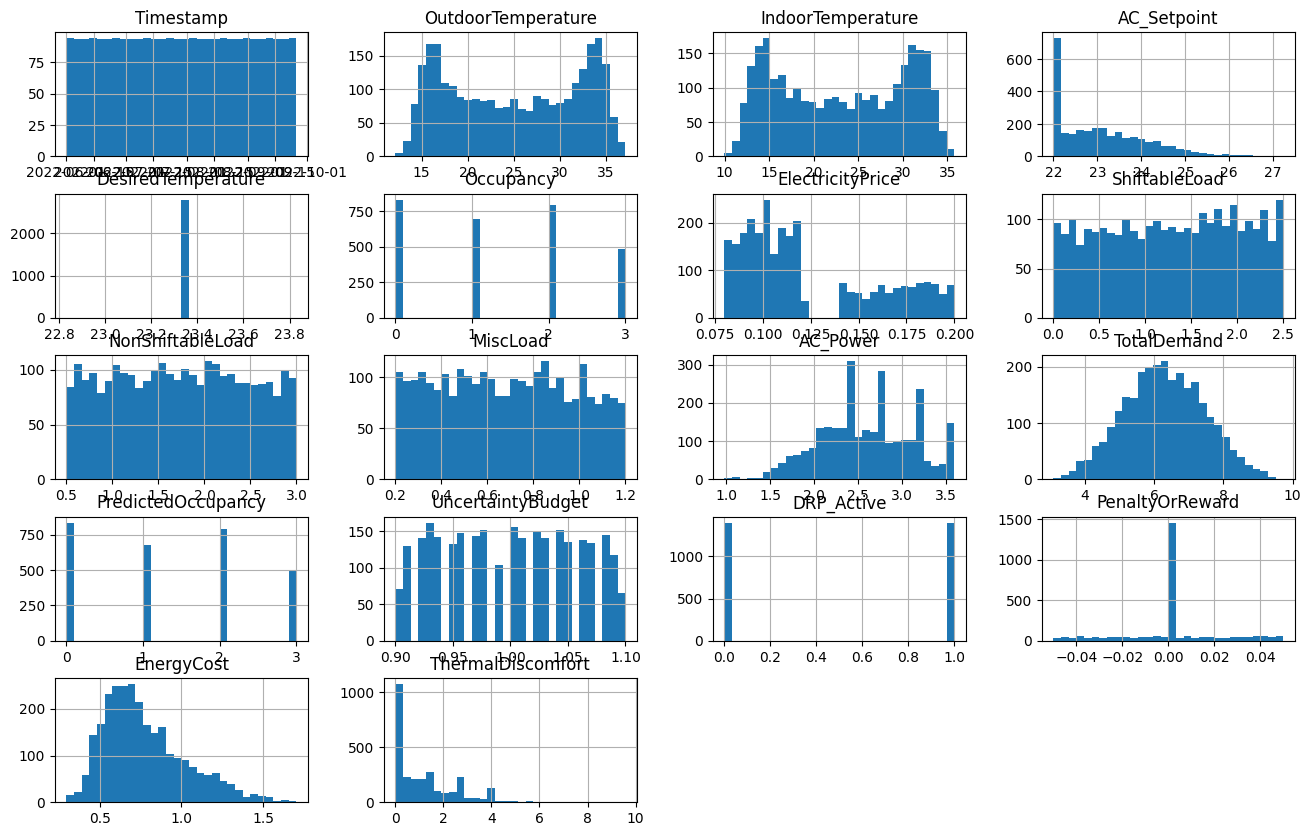

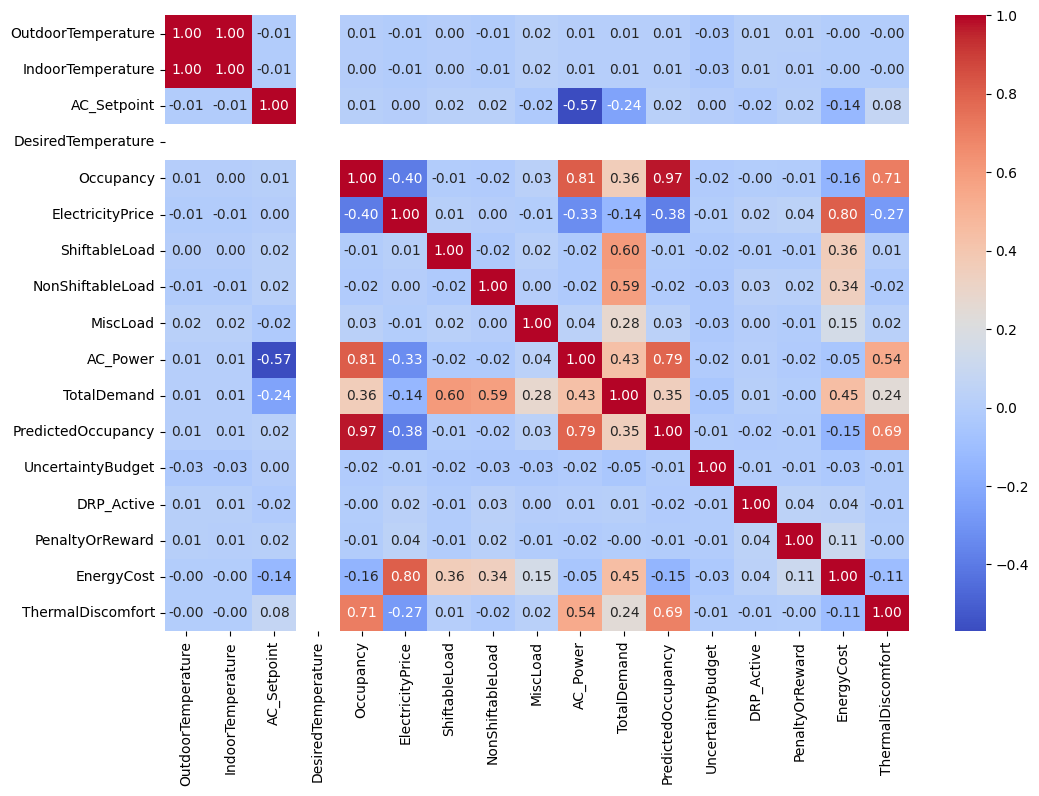

Feature ranking:
1. AC_Power (0.823)
2. AC_Setpoint (0.177)
3. MiscLoad (0.000)
4. NonShiftableLoad (0.000)
5. OutdoorTemperature (0.000)
6. IndoorTemperature (0.000)
7. TotalDemand (0.000)
8. ShiftableLoad (0.000)
9. ElectricityPrice (0.000)
10. DesiredTemperature (0.000)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000225 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2142
[LightGBM] [Info] Number of data points in the train set: 2240, number of used features: 9
[LightGBM] [Info] Start training from score 1.319643
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

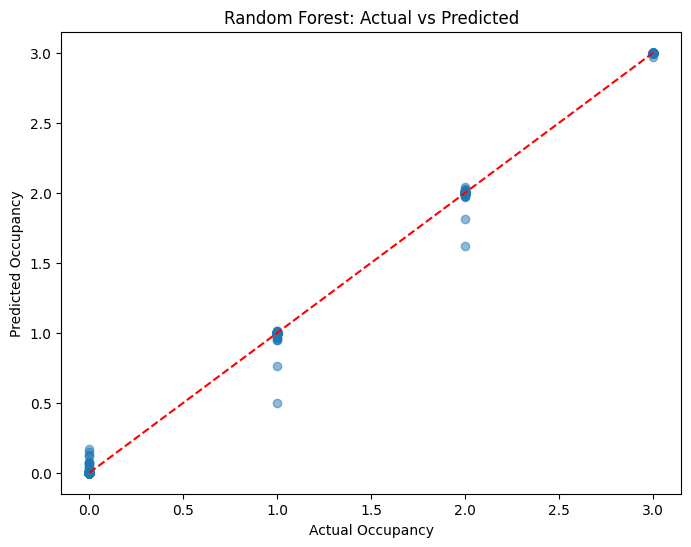

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 1. Load Data
df = pd.read_csv("residential_demand_response_dataset.csv")

# 2. Standardize Column Names (remove spaces, replace with underscores)
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("-", "_")

# 3. Data Preprocessing
df = df.dropna()          # Remove missing values
df = df.drop_duplicates() # Remove duplicates

# Convert Timestamp to datetime if exists
if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# 4. EDA (Exploratory Data Analysis)
print(df.describe())

# Histograms
df.hist(bins=30, figsize=(16, 10))
plt.show()

# Correlation Heatmap (numeric columns only)
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

# 5. Define Input Features and Target
input_features = [
    "OutdoorTemperature", "IndoorTemperature", "AC_Setpoint", "DesiredTemperature",
    "ElectricityPrice", "ShiftableLoad", "NonShiftableLoad", "MiscLoad", "AC_Power", "TotalDemand"
]
target_col = "Occupancy"

# Check if all features exist in df
missing_cols = [col for col in input_features + [target_col] if col not in df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in CSV: {missing_cols}")

X = df[input_features]
y = df[target_col]

# 6. Feature Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 7. Optional: Feature Importance (Random Forest)
rf_temp = RandomForestRegressor(n_estimators=50, random_state=1)
rf_temp.fit(X_scaled, y)
importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(len(input_features)):
    print(f"{f+1}. {input_features[indices[f]]} ({importances[indices[f]]:.3f})")

# 8. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 9. Model Training

# a) Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
joblib.dump(rf, "model_random_forest.pkl")

# b) LightGBM
lgbm = LGBMRegressor(n_estimators=100, random_state=0)
lgbm.fit(X_train, y_train)
joblib.dump(lgbm, "model_lightgbm.pkl")

# c) MLP-ANN
mlp = MLPRegressor(hidden_layer_sizes=(32, 32), activation='relu', max_iter=300, random_state=0)
mlp.fit(X_train, y_train)
joblib.dump(mlp, "model_mlp_ann.pkl")

# 10. Model Evaluation
def evaluate(model, X, y):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    print(f"MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")
    return mse, rmse, mae, r2

print("\nRandom Forest Performance:")
evaluate(rf, X_test, y_test)

print("\nLightGBM Performance:")
evaluate(lgbm, X_test, y_test)

print("\nMLP-ANN Performance:")
evaluate(mlp, X_test, y_test)

# 11. Optional: Plot Predicted vs Actual for Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf.predict(X_test), alpha=0.5)
plt.xlabel("Actual Occupancy")
plt.ylabel("Predicted Occupancy")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # 45-degree line
plt.show()


In [7]:
# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save test data
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")


['y_test.pkl']